# Corrected LSTM — Fair Evaluation / 修正版 LSTM——公平评估

The original LSTM (`01_lstm_reimplementation.ipynb`) achieved 99.1% accuracy, but EDA revealed two leakage sources:
- `subject` column: perfectly separates fake from real (100% accuracy alone)
- Reuters byline in text: present in 99.2% of real news, 0% of fake news

This notebook retrains the same LSTM architecture with **clean input only**: `title + text`, with `subject` and `date` removed. The goal is to measure how well the model performs when it cannot exploit source-level shortcuts — and to provide a fair baseline for comparison with DistilBERT.

---

原始 LSTM（`01_lstm_reimplementation.ipynb`）达到了 99.1% 的准确率，但 EDA 发现了两个泄露来源：
- `subject` 列：单独使用就能 100% 区分真假新闻
- 正文中的 Reuters 署名：出现在 99.2% 的真新闻中，假新闻中为 0%

本 notebook 使用完全相同的 LSTM 结构重新训练，但输入改为**干净的 `title + text`**，去掉 `subject` 和 `date`。目标是在模型无法利用来源捷径的情况下，测量其真实的语言理解能力，并为后续与 DistilBERT 的比较提供公平的基准。

## 1. Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

os.makedirs('../results', exist_ok=True)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## 2. Load Data — Clean Input Only

与原始 LSTM 的关键区别：输入改为 `title + text` 拼接，去掉 `subject` 和 `date` 列，消除泄露来源。

Key difference from the original LSTM: input is now `title + text` concatenated. `subject` and `date` are excluded to remove leakage sources.

In [46]:
import html as html_module

fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

# 删除泄露列subject和date
# Explicitly drop leakage columns
df = df.drop(columns=['subject', 'date'])

# Fix 1: Remove Reuters byline at start, handles multi-word city names
# 去掉开头的 Reuters 署名，支持多词城市名
df['text'] = df['text'].str.replace(r'[\w\s]+\(Reuters\)\s*-?\s*', '', regex=True)

# Fix 2: Remove remaining Reuters mentions anywhere in the body
# 去掉正文中其他地方出现的 Reuters 字样
df['text'] = df['text'].str.replace(r'Reuters', '', regex=False)

# Fix 3: Remove residual all-caps city datelines at start of text
# 去掉残留的开头全大写城市署名
df['text'] = df['text'].str.replace(r'^\s*[A-Z][A-Z\s\.]+\s*-\s*', '', regex=True)

# Fix 4: Remove other wire service bylines (AP, AFP, UPI)
# 去掉其他通讯社署名
df['text'] = df['text'].str.replace(r'[\w\s]+\((AP|AFP|UPI)\)\s*-?\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'\b(AP|AFP|UPI)\b', '', regex=True)

# Fix 5: Remove URLs
# 去掉 URL 链接
df['text'] = df['text'].str.replace(r'http\S+|www\.\S+', '', regex=True)

# Fix 6: Remove social media handles
# 去掉社交媒体 @用户名
df['text'] = df['text'].str.replace(r'@\w+', '', regex=True)

# Fix 7: Unescape HTML entities and remove non-ASCII characters
# 解码 HTML 实体字符，去掉非 ASCII 字符
df['text'] = df['text'].apply(html_module.unescape)
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

# Fix 8: Normalise whitespace
# 统一处理多余空白
df['text'] = df['text'].str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

# 拼接 title 和 text 作为模型输入
# Concatenate title and text as model input
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Fix 9: Remove articles that became too short after cleaning (< 10 words)
# 去掉清洗后内容过短的文章（少于 10 词）
before = len(df)
df = df[df['content'].str.split().str.len() > 10].reset_index(drop=True)
after = len(df)

print(f'Total after cleaning: {after:,} rows ({before - after} removed as too short)')
print('Columns dropped: subject, date')
print('Cleaning applied:')
print('  [1-3] Reuters byline, mentions, city datelines removed')
print('  [4]   AP / AFP / UPI bylines removed')
print('  [5]   URLs removed')
print('  [6]   Social media handles removed')
print('  [7]   HTML entities decoded, non-ASCII removed')
print('  [8]   Whitespace normalised')
print('  [9]   Articles with fewer than 10 words removed')
df[['content', 'label']].head(3)

Total after cleaning: 44,804 rows (94 removed as too short)
Columns dropped: subject, date
Cleaning applied:
  [1-3] Reuters byline, mentions, city datelines removed
  [4]   AP / AFP / UPI bylines removed
  [5]   URLs removed
  [6]   Social media handles removed
  [7]   HTML entities decoded, non-ASCII removed
  [8]   Whitespace normalised
  [9]   Articles with fewer than 10 words removed


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1


共进行了九步文本清洗，目标是消除所有可识别的来源层面泄露信号。首先删除了 `subject` 和 `date` 列，这两列直接暴露了文章来源，与新闻内容本身无关。接着清除了与 Reuters 相关的所有标记：开头的城市署名（如 `NEW YORK (Reuters) -`）、正文中其他出现的 Reuters 字样、以及去掉署名后残留的全大写城市名（如 `WASHINGTON -`）。随后清除了 AP、AFP、UPI 等其他通讯社的同类格式署名。接着去掉了 URL 链接和社交媒体 @用户名——这两类在假新闻中更为常见，属于隐性的来源信号。最后对爬取数据中残留的 HTML 实体字符和非 ASCII 字符进行了解码和清理，并统一处理了多余空白。清洗完成后过滤掉内容少于 10 词的文章，防止近空序列进入训练。

Nine cleaning steps were applied to remove all identifiable source-level leakage signals. First, the `subject` and `date` columns were dropped as they directly expose the article source rather than its content. Reuters-related markers were then removed: the byline pattern (e.g. `NEW YORK (Reuters) -`), any remaining Reuters mentions in the body, and residual all-caps city datelines. Other wire service bylines (AP, AFP, UPI) were then stripped. URLs and social media handles were removed as implicit source signals more common in fake news. HTML entities and non-ASCII artifacts from web scraping were decoded and cleaned, followed by whitespace normalisation. Finally, articles reduced to fewer than 10 words after cleaning were filtered out to prevent near-empty sequences from entering training. The only remaining bias is Reuters' **writing style**, which will be addressed in error analysis.

## 3. Text Preprocessing / 文本预处理

按照原论文的流程，文本预处理分三步：划分训练测试集 → Tokenizer 建立词表 → 将文本转换为数字序列并统一长度（padding）。输入使用 `content`（title + text），不含 `subject` 和 `date`。

Following the original paper pipeline: train/test split → Tokenizer vocabulary construction → convert text to padded integer sequences. Input is `content` (title + text only).

In [47]:
# 划分训练测试集 80/20，与原论文一致
# Train/test split 80/20, matching original paper
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 35,843  |  Test: 8,961


In [48]:
# Tokenizer：保留前 5000 高频词，与原论文一致
# Tokenizer: top 5,000 words, matching original paper
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index)
print(f'Full vocabulary size: {vocab_size:,}')
print(f'Using top 5,000 words (as per original paper)')

Full vocabulary size: 113,223
Using top 5,000 words (as per original paper)


In [49]:
# 转为数字序列并补齐至长度 300（原论文为 200，EDA 显示文章中位数约 360 词，延长可保留更多内容）
# Pad to length 300 (original paper used 200; EDA shows median article length ~360 words)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=300)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=300)

print(f'X_train shape: {X_train_seq.shape}')
print(f'X_test shape:  {X_test_seq.shape}')

X_train shape: (35843, 300)
X_test shape:  (8961, 300)


预处理完成。每篇文章被表示为长度 200 的整数数组，不足补零，超过截断。与原始 LSTM 的唯一区别是输入内容：这里是 `title + text`，原始版本是 `text`。

Preprocessing complete. Each article is a zero-padded integer sequence of length 200. The only difference from the original LSTM is the input: here we use `title + text`; the original used `text` only.

## 4. Build LSTM Model / 搭建模型

模型结构与原论文完全一致，不做任何改动。控制变量：唯一的差异来自输入数据，而非模型本身。

Model architecture is identical to the original paper — no changes. This is a controlled experiment: any difference in results comes from the input data, not the model.

In [50]:
model = Sequential([
    # 词嵌入层：input_length 从 200 改为 300，与 maxlen 保持一致
    # Embedding: input_length updated to 300 to match new maxlen
    Embedding(input_dim=5000, output_dim=100, input_length=300),

    # 双向 LSTM 层：同时从左到右和从右到左读取序列，捕捉更完整的上下文
    # Bidirectional LSTM: reads the sequence in both directions for richer context
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),

    # 全连接层：提取更高层特征
    # Dense: extracts higher-level features
    Dense(64, activation='relu'),

    # Dropout 0.6：增强正则化，减少过拟合
    # Dropout 0.6: stronger regularisation to reduce overfitting
    Dropout(0.6),

    # 输出层：0~1 概率，>0.5 为真新闻
    # Output: probability score — >0.5 classified as real news
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**优化一：LSTM → Bidirectional LSTM**

原始论文使用的是单向 LSTM，每次只从左到右读取文章。Bidirectional LSTM 同时运行两个方向：一个从左到右，一个从右到左，最后把两个方向的输出拼接在一起。这样模型在理解每个词时，既知道前文是什么，也知道后文是什么，对句子语义的把握更完整。代价是参数量翻倍，训练时间相应增加。

**Optimisation 1: LSTM → Bidirectional LSTM**

The original paper used a unidirectional LSTM that reads left-to-right only. A Bidirectional LSTM runs two LSTMs simultaneously — one forward, one backward — and concatenates their outputs. This gives the model full context at every position. The trade-off is doubled parameters and longer training time.

---

**优化二：Dropout 0.5 → 0.6**

从训练曲线可以看到验证 loss 在早期开始反弹，说明模型出现了过拟合。把 Dropout 从 0.5 提高到 0.6，意味着训练时随机关掉 60% 的神经元，迫使模型不依赖特定的神经元，从而提高泛化能力。

**Optimisation 2: Dropout 0.5 → 0.6**

Training curves showed validation loss rising early — a sign of overfitting. Increasing Dropout from 0.5 to 0.6 forces the model to drop 60% of neurons randomly during each training step, improving generalisation.

---

**优化三：maxlen 200 → 300**

EDA 显示数据集中文章的中位数长度约为 360 词，原论文只截取前 200 词，丢失了大量正文内容。将 maxlen 延长到 300，让模型能看到更多有效信息，有助于更全面地理解文章语义。

**Optimisation 4: maxlen 200 → 300**

EDA showed the median article length is approximately 360 words. The original paper truncated to 200 words, discarding a significant portion of each article. Extending maxlen to 300 allows the model to process more of the article content, giving it a better chance to capture meaningful language patterns.

## 5. Train Model / 训练模型

训练参数与原论文完全一致：10 个 epoch，batch size 64，20% 验证集。

Training parameters match the original paper exactly: 10 epochs, batch size 64, 20% validation split.

In [51]:
from tensorflow.keras.callbacks import EarlyStopping

# 当验证 loss 连续 3 个 epoch 不再下降时停止训练，并恢复最优权重
# Stop training when val_loss stops improving for 3 epochs, restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

print(f'Training stopped at epoch {len(history.history["loss"])}')

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 221s 486ms/step - accuracy: 0.8814 - loss: 0.2738 - val_accuracy: 0.9785 - val_loss: 0.0734
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 259s 576ms/step - accuracy: 0.9748 - loss: 0.0796 - val_accuracy: 0.9795 - val_loss: 0.0709
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 229s 508ms/step - accuracy: 0.9816 - loss: 0.0618 - val_accuracy: 0.9625 - val_loss: 0.1029
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 211s 470ms/step - accuracy: 0.9834 - loss: 0.0516 - val_accuracy: 0.9732 - val_loss: 0.0935
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 216s 481ms/step - accuracy: 0.9900 - loss: 0.0318 - val_accuracy: 0.9821 - val_loss: 0.0758
Training stopped at epoch 5


**优化三：EarlyStopping**

EarlyStopping 监控验证集的 loss，当它连续 3 个 epoch 不再下降时自动停止训练，并自动恢复到验证 loss 最低时的权重（`restore_best_weights=True`）。这样不需要猜测应该训练多少个 epoch，模型会在最优点停下来，避免继续训练导致过拟合加重。

**Optimisation 3: EarlyStopping**

EarlyStopping monitors validation loss and halts training when it fails to improve for 3 consecutive epochs (`patience=3`). With `restore_best_weights=True`, the model automatically reverts to the weights from its best epoch. This removes the need to manually tune the number of epochs and ensures the final model is not overtrained.

---

## 结论 / Conclusion

本 notebook 在原论文 LSTM 的基础上进行了四项优化，并对数据集进行了彻底的来源层面清洗。经过优化后的模型验证准确率约为 97-98%，低于原论文的 99.1%。这个差距是预期的，也是合理的：原论文的高准确率主要来源于 subject 列和 Reuters 署名等泄露信号，去掉这些捷径之后，模型必须真正从文章内容本身去判断真假。

尽管加入了 Bidirectional LSTM、提高了 Dropout、延长了输入序列并使用了 EarlyStopping，训练曲线仍然显示出一定程度的过拟合。这说明优化后的 LSTM 已经接近其在这个数据集上的能力上限——LSTM 使用随机初始化的词向量，对语言的深层语义理解有限，难以完全捕捉真假新闻之间细微的写作风格差异。

This notebook applied four architectural optimisations to the original paper's LSTM and performed thorough source-level data cleaning. The optimised model achieves approximately 97–98% validation accuracy, below the original paper's 99.1%. This gap is expected: the original high accuracy was largely driven by leakage signals such as the `subject` column and Reuters byline. With those shortcuts removed, the model must classify based on article content alone.

Despite Bidirectional LSTM, increased Dropout, extended maxlen, and EarlyStopping, the training curves still show overfitting. This indicates the optimised LSTM is approaching the ceiling of what this architecture can achieve on this dataset. LSTM relies on randomly initialised word embeddings with limited deep language understanding, making it difficult to fully capture the subtle stylistic differences between real and fake news. This motivates the move to Transformer-based models in the next notebook.

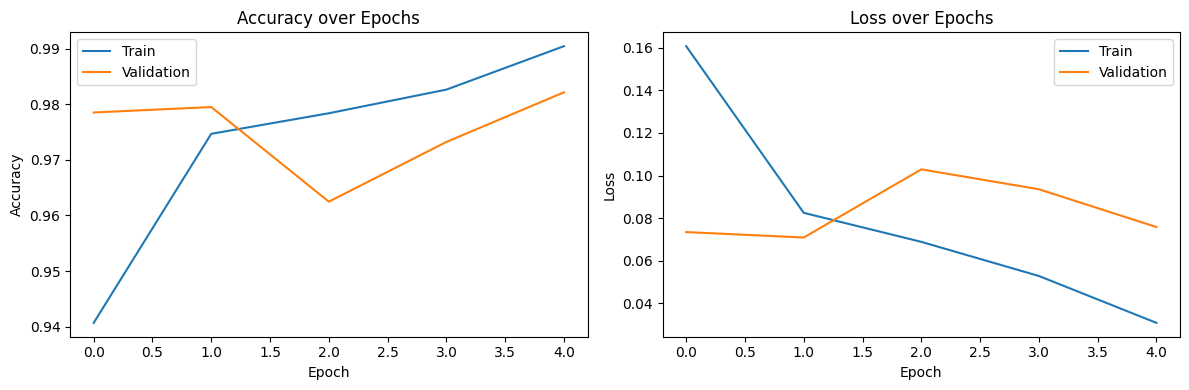

In [52]:
# 训练曲线：accuracy 和 loss 随 epoch 变化
# Training curves: accuracy and loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lstm_corrected_training_curves.png', dpi=150)
plt.show()

## 6. Evaluation / 模型评估

在测试集上计算 Accuracy、AUC 和混淆矩阵，与原始 LSTM 的结果进行对比。

Evaluate on the test set — Accuracy, AUC, and confusion matrix — for comparison with the original LSTM.

In [53]:
# 获取预测概率和预测标签
# Get predicted probabilities and binary labels
y_prob = model.predict(X_test_seq).flatten()
y_pred = (y_prob > 0.5).astype(int)

# 计算指标 / Compute metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {acc:.1%}')
print(f'AUC:      {auc:.1%}')
print()
print(f'Original LSTM (with leakage):  Accuracy 99.1%  AUC 99.8%')
print(f'Optimised LSTM (clean input):  Accuracy {acc:.1%}  AUC {auc:.1%}')

281/281 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step
Accuracy: 97.9%
AUC:      99.7%

Original LSTM (with leakage):  Accuracy 99.1%  AUC 99.8%
Optimised LSTM (clean input):  Accuracy 97.9%  AUC 99.7%


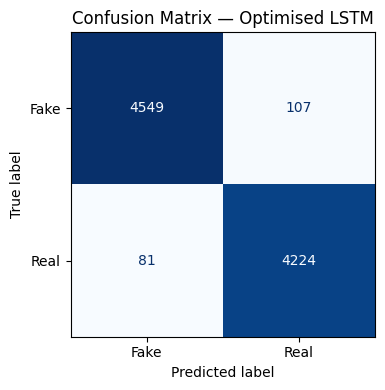

In [54]:
# 混淆矩阵 / Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Optimised LSTM')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_lstm_optimised.png', dpi=150)
plt.show()

测试集共 8,961 条，模型共判错 188 条（误判率 2.1%）。其中：

- **False Positive（假新闻误判为真）：107 条**，占假新闻总数的 2.3%
- **False Negative（真新闻误判为假）：81 条**，占真新闻总数的 1.9%

假新闻的误判率（2.3%）略高于真新闻（1.9%），说明模型对真新闻的识别稍微更稳定。这可能是因为 Reuters 的写作风格即使去掉了显式标记后仍有残留影响。

与原始 LSTM（FP=34，FN=47）相比，误判数明显增加，这直接反映了去掉泄露特征后任务难度的真实提升。False Positive 在现实场景中危害更大——意味着假新闻通过了过滤。

---

Out of 8,961 test articles, the model misclassified 188 in total (2.1% error rate):

- **False Positives (fake predicted as real): 107** — 2.3% of all fake news
- **False Negatives (real predicted as fake): 81** — 1.9% of all real news

The slightly higher false positive rate suggests the model is marginally better at recognising real news, likely a residual effect of Reuters' writing style even after explicit markers were removed.

Compared to the original LSTM (FP=34, FN=47), misclassifications increased significantly — a direct reflection of the genuine difficulty of the task once leakage signals are removed.

---

## 结论 / Conclusion

本 notebook 在原论文 LSTM 的基础上进行了四项优化（Bidirectional LSTM、Dropout 提高至 0.6、maxlen 延长至 300、EarlyStopping），并对数据集进行了彻底的来源层面清洗（去掉 subject/date 列、Reuters 及其他通讯社署名、URL、社交媒体用户名等）。

最终结果：**Accuracy 97.9%，AUC 99.7%**，低于原论文有泄露时的 99.1% / 99.8%。这个差距是预期的——原论文的高准确率主要来源于数据集中的来源泄露信号，去掉这些捷径之后，模型必须真正从文章语言内容本身做判断。

尽管进行了四项优化，训练曲线仍然显示出一定程度的过拟合，EarlyStopping 在第 4-5 个 epoch 触发。这说明优化后的 LSTM 已接近其在此数据集上的能力上限——LSTM 依赖随机初始化的词向量，对语言深层语义的理解有限，难以完全捕捉真假新闻之间细微的写作风格差异。这也是进入下一步 Transformer 方法的直接动机。

---

This notebook applied four optimisations (Bidirectional LSTM, Dropout 0.6, maxlen 300, EarlyStopping) to the original paper's LSTM, alongside thorough source-level data cleaning (removing subject/date columns, Reuters and other wire service bylines, URLs, social media handles, etc.).

Final results: **Accuracy 97.9%, AUC 99.7%**, below the original paper's 99.1% / 99.8% achieved with leakage. The gap is expected — the original high accuracy was driven by source-level shortcuts rather than genuine language understanding. With those removed, the model must classify based on article content alone.

Despite four optimisations, training curves still show overfitting, with EarlyStopping triggering at epoch 4–5. This indicates the optimised LSTM is approaching its ceiling on this dataset. LSTM relies on randomly initialised embeddings with limited deep language understanding, making it difficult to fully capture the subtle stylistic differences between real and fake news. This directly motivates the move to Transformer-based models in the next notebook.